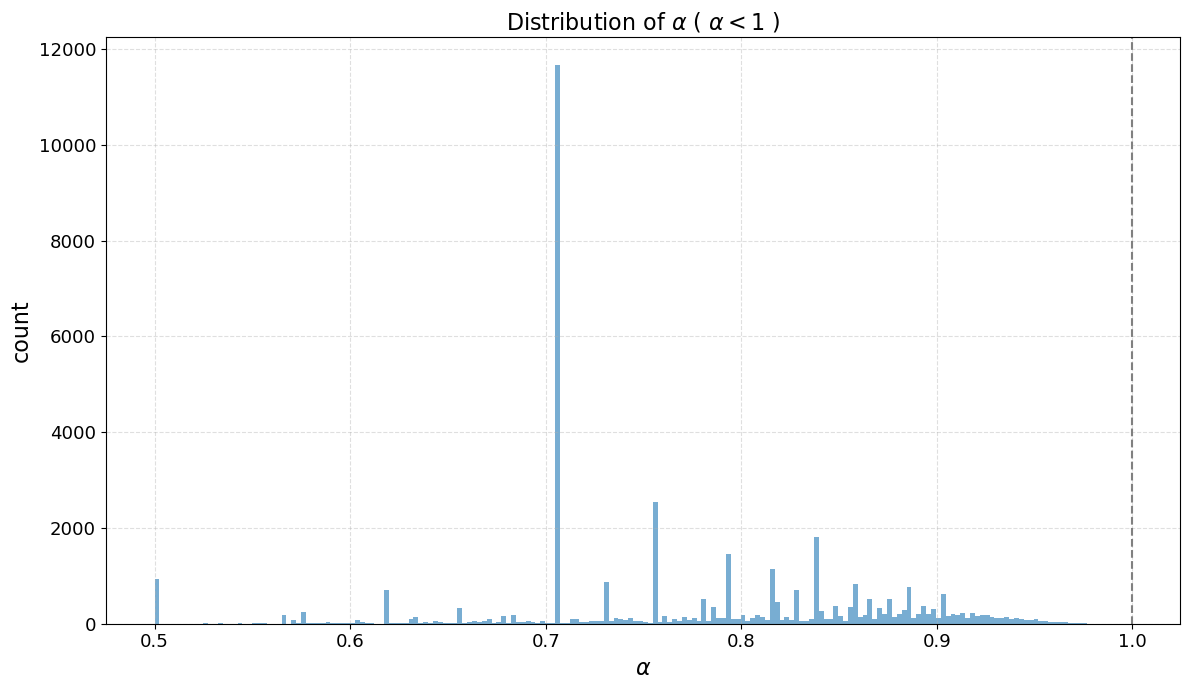

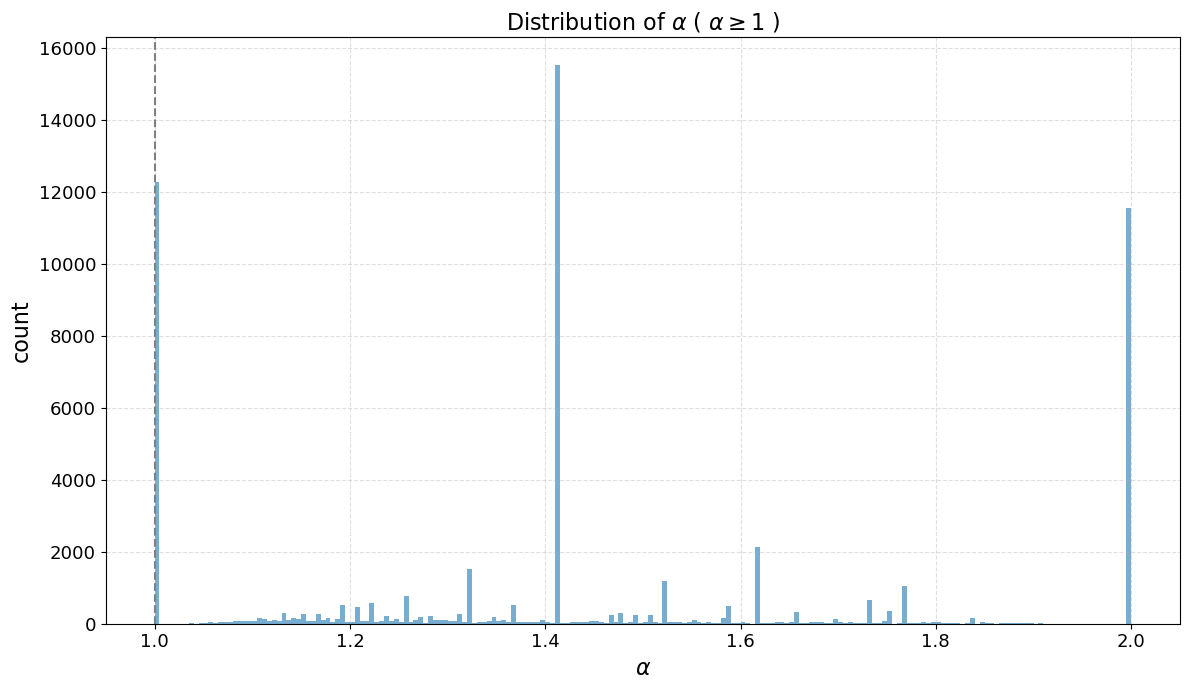

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_alpha_distribution(alpha, title_text, outpath_pdf, outpath_png,
                            bins="fd", density=False, show_logy=False):
    alpha = np.asarray(alpha, dtype=float)
    alpha = alpha[np.isfinite(alpha)]
    if alpha.size == 0:
        print(f"[WARN] No data for: {title_text}")
        return

    fig, ax = plt.subplots(figsize=(12, 7))

    ax.hist(alpha, bins=bins, density=density, alpha=0.6, edgecolor="none")
    ax.axvline(1.0, linestyle="--", linewidth=1.5, color="gray")

    ax.set_xlabel(r"$\alpha$", fontsize=16)
    ax.set_ylabel("density" if density else "count", fontsize=16)
    ax.set_title(title_text, fontsize=16)

    ax.grid(linestyle="--", alpha=0.4)
    ax.tick_params(axis="both", which="major", labelsize=13)

    if show_logy:
        ax.set_yscale("log")

    fig.tight_layout()
    fig.savefig(outpath_pdf, bbox_inches="tight", dpi=400)
    #fig.savefig(outpath_png, bbox_inches="tight", dpi=400)
    plt.show()


def main():
    out_dir = r"Data\New_Bound_Randomize_Topo_and_Kinetics_order2_accuracy_1e-4\results_order2"
    data_path = os.path.join(out_dir, "growth_factors.dat")

    # ---- read saved data (tab-separated) ----
    df = pd.read_csv(data_path, sep="\t")

    # ---- classification tolerance (match your simulation logic) ----
    tol_alpha = 1e-4

    alpha = df["alpha"].to_numpy(dtype=float)

    # α < 1  vs α ≥ 1 (includes α≈1 in the ≥1 class)
    mask_lt = alpha < (1.0 - tol_alpha)
    mask_ge = ~mask_lt

    alpha_lt = alpha[mask_lt]
    alpha_ge = alpha[mask_ge]

    # ---- plot settings ----
    # bins="fd" uses Freedman–Diaconis; or set an int like bins=120
    bins = "fd"
    density = False     # set True if you want normalized distributions
    show_logy = False   # set True if α=1 spike dominates

    plot_alpha_distribution(
        alpha_lt,
        title_text=r"Distribution of $\alpha$ ( $\alpha < 1$ )",
        outpath_pdf=os.path.join(out_dir, "alpha_dist_lt1.pdf"),
        outpath_png=os.path.join(out_dir, "alpha_dist_lt1.png"),
        bins=200,
        density=density,
        show_logy=show_logy
    )

    plot_alpha_distribution(
        alpha_ge,
        title_text=r"Distribution of $\alpha$ ( $\alpha \geq 1$ )",
        outpath_pdf=os.path.join(out_dir, "alpha_dist_ge1.pdf"),
        outpath_png=os.path.join(out_dir, "alpha_dist_ge1.png"),
        bins=200,
        density=density,
        show_logy=show_logy
    )


if __name__ == "__main__":
    main()